In [22]:
from __future__ import annotations

import random
import numpy as np
import simpy

# Run the simulationimport matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np


class Job:
    def __init__(self, task, duration, targets):
        self.task = task
        self.duration = duration
        self.targets = targets
        self.end = 0

    def update_end(self, new_end):
        if new_end > self.end:
            self.end = new_end
        return


class Task:
    def __init__(self, id, jobs=None):
        if jobs is None:
            jobs = []
        self.id = id
        self.jobs = jobs
        self.end = 0

    def update_end(self, new_end):
        if new_end > self.end:
            self.end = new_end
        return


class Queues:
    QPUs = ["qpu0", "qpu1", "qpu2"]

    def __init__(self, env):
        self.q = {qpu: [] for qpu in self.QPUs}
        self.end = {qpu: 0 for qpu in self.QPUs}
        self.sym_queue = {qpu: simpy.Store(env) for qpu in self.QPUs}

    def get_shortest_q(self, targets):
        # choose shortest queue within targets
        return min([qpu for qpu in targets], key=self.end.get)
    
    def load_to_simpy_queue(self):
        for qpu, jobs in self.q.items():
            for job in jobs:
                self.sym_queue[qpu].put(job)

def create_tasks(M, N, O):
    tasks = []
    for i in range(M):
        new_task = Task(id=i)

        jobs = []
        num_jobs = random.randint(1, N)
        for _ in range(num_jobs):
            duration = random.randint(1, O)
            # choose random subset of targets
            targets = random.sample(Queues.QPUs, random.randint(1, len(Queues.QPUs)))
            jobs.append(Job(new_task, duration, targets))

        new_task.jobs = jobs
        tasks.append(new_task)
    return tasks


def distribute_equally(new_task, queues, scheduler):
    sorted_jobs = sorted(new_task.jobs, key=lambda job: job.duration, reverse=True)
    # choose shortest queue
    for job in sorted_jobs:
        q_name = queues.get_shortest_q(job.targets)
        shortest_q = queues.q[q_name]
        scheduler(job, new_task, shortest_q)
        queues.end[q_name] += job.duration


def skipping_scheduler(new_job, new_task, queue):
    if queue == []:
        queue.append(new_job)
        new_task.update_end(new_job.duration)
        new_job.update_end(new_job.duration)

    else:
        for i, job in enumerate(reversed(queue)):
            predicted_end = job.end + new_job.duration
            task_end = job.task.end
            if predicted_end < task_end:  # can skip in line (wo delaying other task)
                if new_task.end < task_end:  # should skip in line (for overall speedup)
                    if i != len(queue) - 1:  # have not reached the end of the line
                        job.end = predicted_end  # update end time of current job in line
                        continue  # check next job in line

            queue.insert(len(queue) - i, new_job)
            new_task.update_end(predicted_end)
            new_job.update_end(predicted_end)
            break


def fifo_scheduler(new_job, new_task, queue):
    last_job = queue[-1] if queue else None
    predicted_end = last_job.end + new_job.duration if last_job else new_job.duration
    queue.append(new_job)
    new_task.update_end(predicted_end)
    new_job.update_end(predicted_end)


def print_queue(queue):
    # enumerate distinct tasks
    for qpu, jobs in queue.q.items():
        durations = str([job.task.id for job in jobs for _ in range(job.duration)])
        print(f'"{qpu}": {"".join(durations)}')
    print("---------------------------------")

    
def run_schedulers(tasks, queue, fifo):
    wait_times, fifo_wait_times = [], []
    for task in tasks:
        distribute_equally(task, queue, skipping_scheduler)
        wait_times.append(task.end / sum([job.duration for job in task.jobs]))
        
        task.end = 0
        distribute_equally(task, fifo, fifo_scheduler)
        fifo_wait_times.append(task.end / sum([job.duration for job in task.jobs]))
    
    return sum(wait_times)/len(tasks), sum(fifo_wait_times)/len(tasks)

In [34]:
def computer(env, queue, results, qpu):
    while True:
        # Get the next job from the queue
        job = yield queue.get()

        # Record the start time
        start = env.now

        # Process the job
        yield env.timeout(job.duration)

        # Record the end time
        end = env.now

        # Update the end time of the job
        job.update_end(end)

        # Store the results
        j_id = str(job.task.id)# + '.' + str(job.task.jobs.index(job))
        results.append((j_id, start, end, qpu))

# Create a SimPy environment
env = simpy.Environment()

# Create a Queues object
queues = Queues(env)

num_tasks, max_jobs, max_duration = 10, 5, 10
tasks = create_tasks(num_tasks, max_jobs, max_duration)

# Distribute tasks evenly among queues
for task in tasks:
    distribute_equally(task, queues, skipping_scheduler)

# Load jobs into the SimPy queues
queues.load_to_simpy_queue()


# Create a list to store the results
results = []

# Start the computer processes
for qpu in queues.QPUs:
    env.process(computer(env, queues.sym_queue[qpu], results, qpu))

# Run the simulation
env.run()

# Get unique job_ids and assign a unique color to each
job_ids = list(set([job_id for job_id, _, _, _ in results]))
colors = cm.rainbow(np.linspace(0, 1, len(job_ids)))
color_map = dict(zip(job_ids, colors))

# Plot the results
plt.figure(figsize=(10, 6))
for job_id, start, end, qpu in results:
    plt.plot([start, end], [queues.QPUs.index(qpu), queues.QPUs.index(qpu)], color=color_map[job_id], label=f'Job {job_id}')
plt.xlabel('Time')
plt.ylabel('QPU')
plt.title('Job Execution Timeline')
plt.yticks(range(len(queues.QPUs)), queues.QPUs)
plt.legend()
plt.show()



TypeError: computer() missing 1 required positional argument: 'qpu'

In [17]:
diff = 0
for num_tasks in range(2, 100):
    for max_jobs in range(1, 10):
         for max_duration in range(1, 10):
            tasks = create_tasks(num_tasks, max_jobs, max_duration)
            
            # Run the scheduler
            queue, fifo = Queues(), Queues()
            wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

            # save max difference in wait time and print associated parameters
            new_diff = fifo_wait_time - wait_time
            if new_diff > diff:
                diff = new_diff
                print(f"Tasks: {num_tasks}, Jobs: {max_jobs}, Duration: {max_duration}, Diff: {diff}")


Tasks: 3, Jobs: 4, Duration: 7, Diff: 0.1166666666666667
Tasks: 3, Jobs: 5, Duration: 9, Diff: 0.22222222222222232
Tasks: 3, Jobs: 6, Duration: 5, Diff: 0.33333333333333326
Tasks: 4, Jobs: 2, Duration: 5, Diff: 0.375
Tasks: 4, Jobs: 7, Duration: 4, Diff: 3.5
Tasks: 14, Jobs: 7, Duration: 7, Diff: 3.680612244897959


KeyboardInterrupt: 

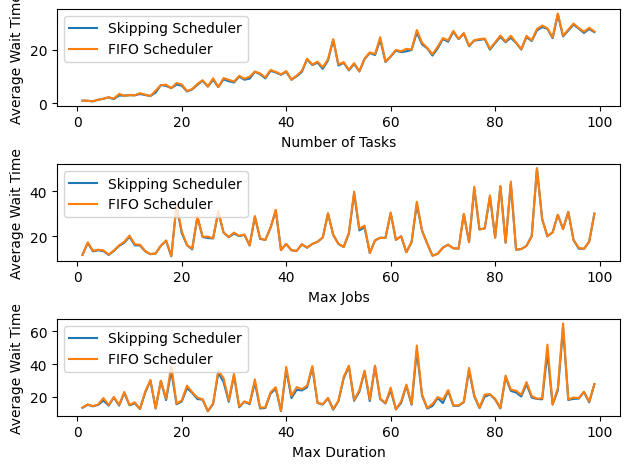

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3)

# Initialize lists to store wait times
wait_times_tasks = []
fifo_wait_times_tasks = []
wait_times_jobs = []
fifo_wait_times_jobs = []
wait_times_duration = []
fifo_wait_times_duration = []

num_samples = 100

for num_tasks in range(1, num_samples):
    tasks = create_tasks(num_tasks, 5, 5)  # use fixed values for max_jobs and max_duration

    # Run the scheduler
    queue, fifo = Queues(), Queues()
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_tasks.append(wait_time)
    fifo_wait_times_tasks.append(fifo_wait_time)

for max_jobs in range(1, num_samples):
    queue, fifo = Queues(), Queues()
    tasks = create_tasks(50, max_jobs, 5)  # use fixed values for num_tasks and max_duration

    # Run the scheduler
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_jobs.append(wait_time)
    fifo_wait_times_jobs.append(fifo_wait_time)

for max_duration in range(1, num_samples):
    queue, fifo = Queues(), Queues()
    tasks = create_tasks(50, 5, max_duration)  # use fixed values for num_tasks and max_jobs

    # Run the scheduler
    wait_time,  fifo_wait_time = run_schedulers(tasks, queue, fifo)

    # Store average wait times
    wait_times_duration.append(wait_time)
    fifo_wait_times_duration.append(fifo_wait_time)

# Plot wait times against number of tasks
axs[0].plot(range(1, num_samples), wait_times_tasks, label='Skipping Scheduler')
axs[0].plot(range(1, num_samples), fifo_wait_times_tasks, label='FIFO Scheduler')
axs[0].set_xlabel('Number of Tasks')
axs[0].set_ylabel('Average Wait Time')

# Plot wait times against max_jobs
axs[1].plot(range(1, num_samples), wait_times_jobs, label='Skipping Scheduler')
axs[1].plot(range(1, num_samples), fifo_wait_times_jobs, label='FIFO Scheduler')
axs[1].set_xlabel('Max Jobs')
axs[1].set_ylabel('Average Wait Time')

# Plot wait times against max_duration
axs[2].plot(range(1, num_samples), wait_times_duration, label='Skipping Scheduler')
axs[2].plot(range(1, num_samples), fifo_wait_times_duration, label='FIFO Scheduler')
axs[2].set_xlabel('Max Duration')
axs[2].set_ylabel('Average Wait Time')

for ax in axs:
    ax.legend()

plt.tight_layout()
plt.show()